# Imports

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms as T
import seaborn as sn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = "/content/drive/MyDrive/datasets/OxforIIIPet"

# Dataset and DataLoader

In [ ]:
pre_transform = T.Compose([
    T.ToTensor(),
    T.Resize(size=(120,120))
])

In [ ]:
dataset_train = OxfordIIITPet(
    root= DATA_DIR,
    split= "trainval",
    download= True,
    target_types= 'category',
    transform= pre_transform
)

dataset_test = OxfordIIITPet(
    root= DATA_DIR,
    split= "test",
    download= True,
    target_types='category',
    transform= pre_transform
)



In [ ]:
def lookat_dataset(dataset, isTensor = False):
  figure = plt.figure(figsize=(8,8))
  rows,cols = 2,2
  for i in range(1,5):
    sample_idx = torch.randint(len(dataset), size=(1, )).item()
    img, label = dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    if isTensor:
      plt.imshow(img.squeeze().permute(1,2,0))
    else:
      plt.imshow(img)
  plt.show

In [ ]:
print(dataset_train[0][0].shape)
print(dataset_train[0][1])

torch.Size([3, 120, 120])
0


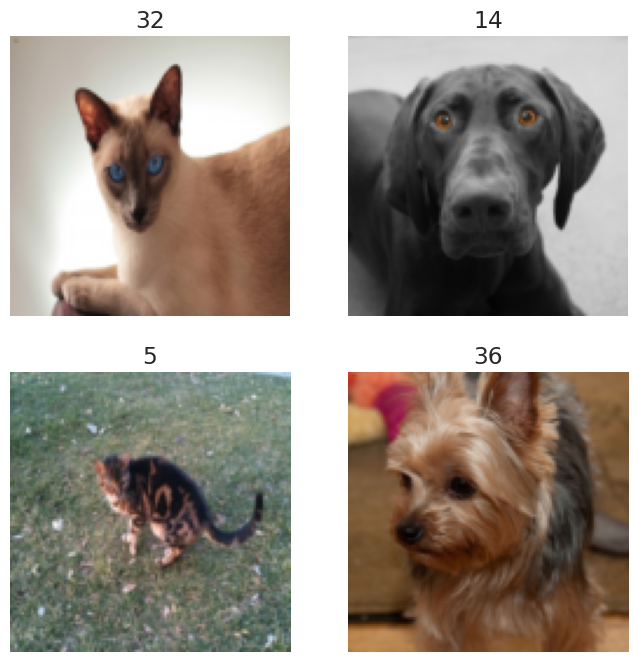

In [ ]:
lookat_dataset(dataset_train, True)

In [ ]:
batch_size = 32
train_dataloader = DataLoader(dataset=dataset_train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(dataset=dataset_test, batch_size=batch_size, shuffle=True)

# Convolutional Neural Network

In [ ]:
class PetNN(nn.Module):
  def __init__(self):
    super().__init__()
    filter_one = (3,3)
    filter_two = (5,5)
    self.convlayers = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=filter_one, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2)),
        nn.Dropout(0.2),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=filter_one, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2)),
        nn.Dropout(0.3),
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=filter_one, padding = 1, stride=2),
        nn.LeakyReLU(),
        nn.MaxPool2d(kernel_size=(2,2)),
        nn.Dropout(0.3),
        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=filter_one, padding = 1),
        nn.ReLU(),
    )

    self.flatten = nn.Flatten()

    self.linear = nn.Sequential(
        nn.Linear(in_features=12544, out_features=128),
        nn.ReLU(),
        nn.Linear(128, 37)
    )
  def forward(self,x):
    v = self.convlayers(x)
    v = self.flatten(v)
    return self.linear(v)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
model = PetNN().to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr = 0.0001)
loss_func = nn.CrossEntropyLoss()

# Train and Test Functions

In [ ]:
def train(model, dataloader, optimizer, lossfunc):
  model.train()
  cum_loss = 0.0
  right = 0
  total_images = 0

  for img, label in dataloader:
    img, label = img.to(device), label.to(device)
    pred = model(img)
    loss = lossfunc(pred, label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    cum_loss += loss.item()
    prev = torch.argmax(pred, dim = 1) #pega o valor de maior probabilidade
    right += (prev == label).sum().item()
    total_images += label.size(0) #size(0) pega a dimensão das labels
  loss = cum_loss/len(dataloader)
  accuracy = right/total_images
  return loss, accuracy

def test(model, dataloader, lossfunc):
  model.eval()
  cum_loss = 0.0
  right = 0
  total_imgs = 0
  with torch.no_grad():
    for img, label in dataloader:
      img, label = img.to(device), label.to(device)
      pred = model(img)
      loss = lossfunc(pred, label)
      cum_loss += loss.item()
      prev = torch.argmax(pred, dim = 1)
      right += (prev == label).sum().item()
      total_imgs += label.size(0)
  loss = cum_loss/len(dataloader)
  accuracy = right/total_imgs
  return loss, accuracy

In [ ]:
epochs = 40

In [ ]:
loss_arr = []
accu_arr = []
for j in range(epochs):
  train_loss, train_accu = train(model, train_dataloader, optimizer, loss_func)
  loss_arr.append(train_loss)
  accu_arr.append(train_accu)
  if (j % 5 == 0):
    print(f'Epoch: {j + 1} - Loss: {train_loss} - Accuracy: {train_accu}')
test_loss, test_accu = test(model, test_dataloader, loss_func)
print(f'Accuracy of the test: {test_accu}')


Epoch: 1 - Loss: 3.6128720718881357 - Accuracy: 0.024728260869565217
Epoch: 6 - Loss: 3.2246548051419466 - Accuracy: 0.11983695652173913
Epoch: 11 - Loss: 2.758345883825551 - Accuracy: 0.23695652173913043
Epoch: 16 - Loss: 2.1334525015043178 - Accuracy: 0.4002717391304348
Epoch: 21 - Loss: 1.3624226668606634 - Accuracy: 0.6046195652173914
Epoch: 26 - Loss: 0.6949533364047175 - Accuracy: 0.7975543478260869
Epoch: 31 - Loss: 0.30245217337556507 - Accuracy: 0.9163043478260869
Epoch: 36 - Loss: 0.15236947695198266 - Accuracy: 0.9592391304347826
Accuracy of the test: 0.116107931316435


# Confusion Matrix and Graphs

In [ ]:
def make_confusion_matrix(model, loader, n_classes):
  confusion_matrix = torch.zeros(n_classes, n_classes, dtype=torch.int64)
  with torch.no_grad():
    for i, (imgs, labels) in enumerate(loader):
      imgs = imgs.to(device)
      labels = labels.to(device)
      outputs = model(imgs)
      _, predicted = torch.max(outputs, 1)
      for t, p in zip(torch.as_tensor(labels, dtype=torch.int64).view(-1),
                      torch.as_tensor(predicted, dtype=torch.int64).view(-1)):
        confusion_matrix[t, p] += 1
  return confusion_matrix

In [ ]:
def plot_graph(x_array, loss_array):
  plt.plot(x_array, loss_array, "b", label = "Train Loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss - Value (%s)")
  plt.title("Loss Value")
  plt.legend()
  plt.show()

In [ ]:
n_classes = 37
conv_confusion_matrix = make_confusion_matrix(model, test_dataloader, n_classes)

<Axes: >

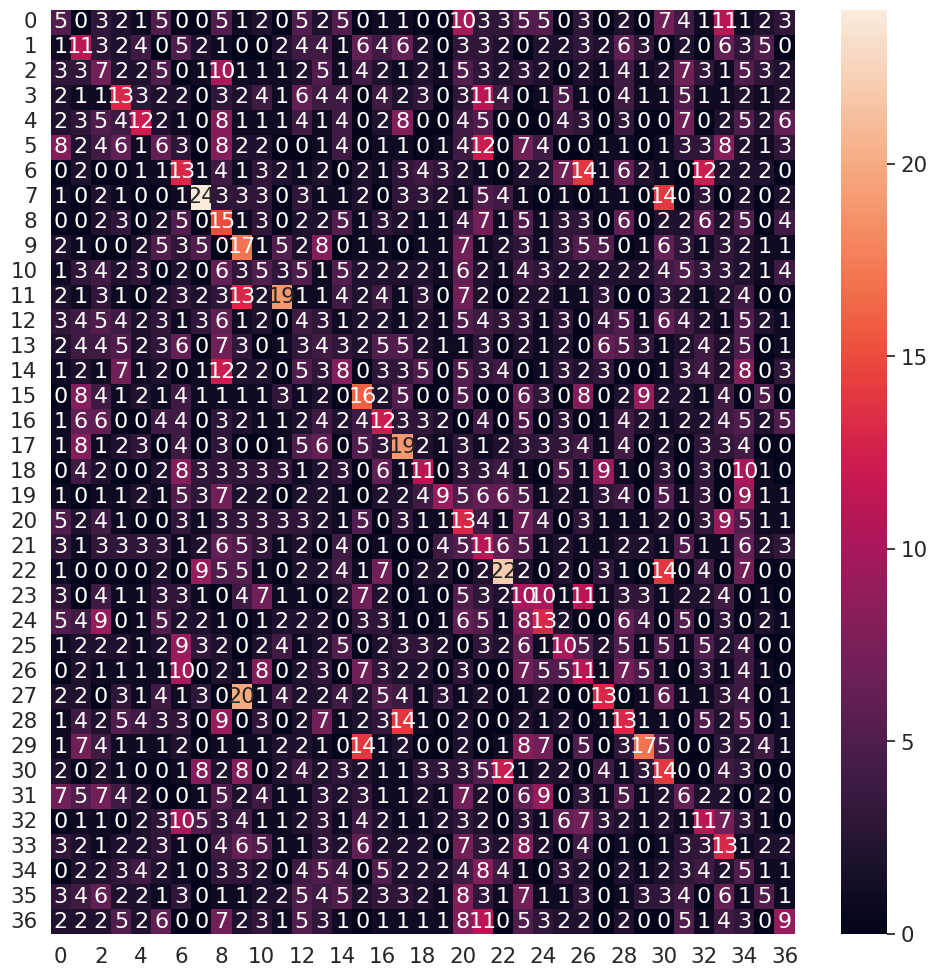

In [ ]:
plt.figure(figsize=(12, 12))
sn.set(font_scale=1.4)
sn.heatmap(conv_confusion_matrix.tolist(),
           annot=True, annot_kws={"size": 16}, fmt='d')


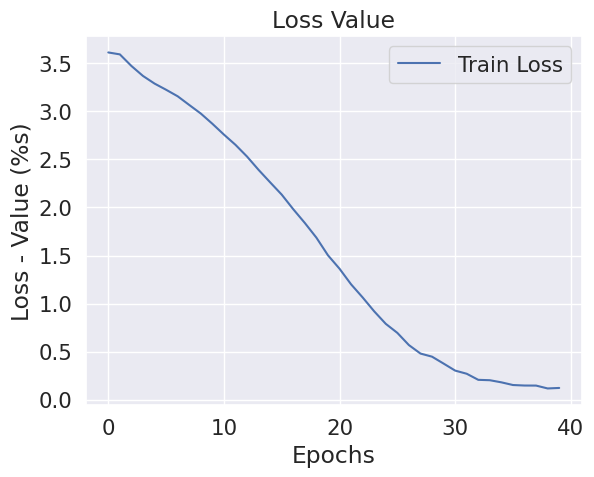

In [ ]:
x = range(epochs)
plot_graph(x, loss_arr)